# Notebook where to build the Tensorflow Recommender Model

## Data Prep

In [1]:
import pandas as pd

customers_csv_path = '/data/processed/customers_df.csv'
customers_df = pd.read_csv(customers_csv_path)
customers_df.head(3)

,customer_id,Active,club_member_status,fashion_news_frequency,age,postal_code,purchased_articles,favorite_sales_channel
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49,974 04,"[625548001, 176209023, 627759010, 697138006, 5...",2.0
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0.0,ACTIVE,NONE,25,WF1 5EY,"[583558001, 639677008, 640244003, 521269001, 6...",2.0
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0.0,ACTIVE,NONE,24,75008,"[663713001, 541518023, 663713001, 578020002, 7...",2.0


In [2]:
customers_df.shape

(1371980, 8)

In [3]:
customers_df.columns

Index(['customer_id', 'Active', 'club_member_status', 'fashion_news_frequency',
       'age', 'postal_code', 'purchased_articles', 'favorite_sales_channel'],
      dtype='object')

In [4]:
customers_df['Active'].unique()

array([0., 1.])

In [5]:
customers_df['club_member_status'].unique()

array(['ACTIVE', 'LEFT CLUB', 'PRE-CREATE'], dtype=object)

In [6]:
import numpy as np

np.random.seed(42)

sample_size = 5000
unique_ids = customers_df['customer_id'].unique()
sampled_ids = np.random.choice(unique_ids, size=sample_size, replace=False)
customers_data = customers_df[customers_df['customer_id'].isin(sampled_ids)].copy()

print(f"Sampled Dataset Shape: {customers_data.shape}")

Sampled Dataset Shape: (5000, 8)


In [7]:
def encode_status(x):
    if x == "PRE-CREATE":
        return 1
    elif x == "ACTIVE":
        return 2
    else:
        return 0

customers_data['club_member_status_encoded'] = customers_data['club_member_status'].apply(lambda x: encode_status(x))

In [8]:
customers_data['fashion_news_frequency'].unique()

array(['NONE', 'Regularly', 'Monthly'], dtype=object)

In [ ]:
def encode_news(x):
    if x == "Regularly":
        return 2
    elif x == "Monthly":
        return 1
    else:
        return 0

customers_data["fashion_news_frequency_encoded"] = customers_data["fashion_news_frequency"].apply(encode_news)

In [10]:
customers_data['favorite_sales_channel'].unique()

array([ 2.,  1., nan])

In [11]:
customers_data.fillna({'favorite_sales_channel': 0}, inplace=True)

In [12]:
customers_data['favorite_sales_channel'].unique()

array([2., 1., 0.])

In [13]:
customers_data.isna().sum()

customer_id                       0
Active                            0
club_member_status                0
fashion_news_frequency            0
age                               0
postal_code                       0
purchased_articles                0
favorite_sales_channel            0
club_member_status_encoded        0
fashion_news_frequency_encoded    0
dtype: int64

In [14]:
import ast

customers_data['purchased_articles'] = customers_data['purchased_articles'].apply(lambda x: (ast.literal_eval(x)))
customers_data['nb_past_purchases'] = customers_data['purchased_articles'].apply(lambda x: len(x))
customers_data['nb_past_purchases'].mean().round(0)

np.float64(23.0)

In [15]:
from itertools import chain

all_articles = set(chain.from_iterable(customers_data["purchased_articles"]))

In [16]:
from sklearn.preprocessing import MinMaxScaler
import joblib

scaler = MinMaxScaler()
scaler.fit(customers_data[["age"]])
customers_data["age_scaled"] = scaler.transform(customers_data[["age"]]) 

joblib.dump(scaler, "/data/scalers/age_scaler.pkl")

['/data/scalers/age_scaler.pkl']

In [17]:
customers_data.head(3)

,customer_id,Active,club_member_status,fashion_news_frequency,age,postal_code,purchased_articles,favorite_sales_channel,club_member_status_encoded,fashion_news_frequency_encoded,nb_past_purchases,age_scaled
321,000f72a562e6a77624d7f6330b9bbaef1ecdfef26a9c14...,0.0,ACTIVE,NONE,36,00520,"[834258003, 834258003, 716545008, 832298003, 8...",2.0,2,0,14,0.281690
396,0012cb3404b7e0a54c6b88b20b35aa8944c264fa9975ac...,0.0,ACTIVE,NONE,28,5611 AE,"[678260005, 654564005, 560270010, 636935006, 6...",1.0,2,0,23,0.169014
433,0014669814e09bf5ab74d7d4d6befa94f303ff2a04b9f6...,1.0,ACTIVE,Regularly,23,02826,[862496001],1.0,2,0,1,0.098592


In [18]:
import tensorflow as tf
import numpy as np

# 1. Shuffle and split the unique customer IDs
unique_article_ids = np.unique(np.array(list(all_articles)).astype(str))
unique_articles_ds = tf.data.Dataset.from_tensor_slices(unique_article_ids)
unique_customer_ids = np.unique(customers_data['customer_id'].values.astype(str))

shuffled_customers = np.random.permutation(unique_customer_ids)
train_size = int(0.8 * len(shuffled_customers))

train_customers = set(shuffled_customers[:train_size])
test_customers = set(shuffled_customers[train_size:])

# 2. Define our sequences
def sequence_generator(customer_set):
    # Filter the dataframe to only include the relevant customers
    subset_df = customers_data[customers_data['customer_id'].isin(customer_set)]
    
    for _, row in subset_df.iterrows():
        articles = [str(a) for a in row['purchased_articles']]
        if len(articles) < 2:
            continue
            
        for i in range(1, len(articles)):
            start_idx = max(0, i - 10)
            history = articles[start_idx:i]
            padded_history = ["PAD"] * (10 - len(history)) + history
            
            yield (
                {
                    "customer_id": str(row["customer_id"]),
                    "history": padded_history,
                    "age": float(row["age_scaled"]),
                    "active": float(row["Active"]),
                    "status": float(row["club_member_status_encoded"]),
                    "news": float(row["fashion_news_frequency_encoded"]),
                    "channel": float(row["favorite_sales_channel"])
                },
                str(articles[i])
            )

output_signature = (
    {
        "customer_id": tf.TensorSpec(shape=(), dtype=tf.string),
        "history": tf.TensorSpec(shape=(10,), dtype=tf.string),
        "age": tf.TensorSpec(shape=(), dtype=tf.float32),
        "active": tf.TensorSpec(shape=(), dtype=tf.float32),
        "status": tf.TensorSpec(shape=(), dtype=tf.float32),
        "news": tf.TensorSpec(shape=(), dtype=tf.float32),
        "channel": tf.TensorSpec(shape=(), dtype=tf.float32),
    },
    tf.TensorSpec(shape=(), dtype=tf.string)
)

# 3. Create the two TF Datasets
train_ds = tf.data.Dataset.from_generator(lambda: sequence_generator(train_customers), output_signature=output_signature).batch(2048).cache().prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(lambda: sequence_generator(test_customers), output_signature=output_signature).batch(512).cache().prefetch(tf.data.AUTOTUNE)

2026-01-16 18:24:05.537338: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1768587850.564718  186496 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13713 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## Modeling

### Create Model

In [19]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [20]:
import tensorflow as tf
import tensorflow_recommenders as tfrs

# --- 1. Define the Query Tower (User + History + Metadata) ---
class QueryTower(tf.keras.Model):
    def __init__(self, embedding_dimension, unique_customer_ids, unique_article_ids):
        super().__init__()
        
        self.user_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_customer_ids, mask_token=None),
            tf.keras.layers.Embedding(
                len(unique_customer_ids) + 1, 
                embedding_dimension,
                embeddings_regularizer=tf.keras.regularizers.l2(1e-6)
            )
        ])

        # Sequential History with LSTM
        self.history_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_article_ids, mask_token="PAD"),
            tf.keras.layers.Embedding(
                len(unique_article_ids) + 1, 
                embedding_dimension, 
                mask_zero=True,
                embeddings_regularizer=tf.keras.regularizers.l2(1e-6)
            ),
            tf.keras.layers.LSTM(embedding_dimension)
        ])

        # Categorical metadata embeddings
        meta_embedding_dim = 8
        self.status_lookup = tf.keras.layers.IntegerLookup(vocabulary=[0, 1, 2], mask_token=None)
        self.status_embedding = tf.keras.layers.Embedding(
            self.status_lookup.vocabulary_size() + 1,
            meta_embedding_dim
        )
        self.news_lookup = tf.keras.layers.IntegerLookup(vocabulary=[0, 1, 2], mask_token=None)
        self.news_embedding = tf.keras.layers.Embedding(
            self.news_lookup.vocabulary_size() + 1,
            meta_embedding_dim
        )
        self.channel_lookup = tf.keras.layers.IntegerLookup(vocabulary=[0, 1, 2], mask_token=None)
        self.channel_embedding = tf.keras.layers.Embedding(
            self.channel_lookup.vocabulary_size() + 1,
            meta_embedding_dim
        )

        # Deeper Fusion MLP with Dropout to prevent overfitting
        self.dense_fuser = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation="relu"),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(embedding_dimension) 
        ])

    def call(self, inputs):
        user_emb = self.user_embedding(inputs["customer_id"])
        hist_emb = self.history_embedding(inputs["history"])

        status_emb = self.status_embedding(self.status_lookup(tf.cast(inputs["status"], tf.int32)))
        news_emb = self.news_embedding(self.news_lookup(tf.cast(inputs["news"], tf.int32)))
        channel_emb = self.channel_embedding(self.channel_lookup(tf.cast(inputs["channel"], tf.int32)))

        metadata = tf.concat([
            tf.cast(tf.expand_dims(inputs["age"], -1), tf.float32),
            tf.cast(tf.expand_dims(inputs["active"], -1), tf.float32),
            status_emb,
            news_emb,
            channel_emb
        ], axis=1)
        
        # Concatenate: (User ID) + (LSTM Context) + (Metadata)
        combined = tf.concat([user_emb, hist_emb, metadata], axis=1)
        return self.dense_fuser(combined)

# --- 2. Define the Candidate Tower ---
embedding_dimension = 128

article_model = tf.keras.Sequential([
    tf.keras.layers.StringLookup(vocabulary=unique_article_ids, mask_token=None),
    tf.keras.layers.Embedding(
        len(unique_article_ids) + 1, 
        embedding_dimension,
        embeddings_regularizer=tf.keras.regularizers.l2(1e-6)
    )
])

# --- 3. Define the Full Recommender Model ---
class FashionModel(tfrs.Model):
    def __init__(self, query_model, candidate_model, unique_articles_ds):
        super().__init__()
        self.query_model = query_model
        self.candidate_model = candidate_model
        
        # ADDED: Temperature to soften the softmax and help learning
        self.task = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(
                candidates=unique_articles_ds.batch(128).map(self.candidate_model)
            ),
            temperature=0.05 
        )

    def compute_loss(self, inputs, training=False):
        features, labels = inputs
        query_embeddings = self.query_model(features)
        positive_candidate_embeddings = self.candidate_model(labels)
        
        return self.task(query_embeddings, positive_candidate_embeddings, compute_metrics=not training)

# --- 4. Initialization and Compilation ---
query_tower = QueryTower(embedding_dimension, unique_customer_ids, unique_article_ids)
model = FashionModel(query_tower, article_model, unique_articles_ds)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))

### Train

In [21]:
import datetime

BATCH_SIZE = 2048
EPOCHS = 100

train = train_ds.shuffle(100_000).prefetch(tf.data.AUTOTUNE)

log_dir = os.path.join("/data/models/logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
checkpoint_path = "/data/models/checkpoints/fashion_model_best.weights.h5"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=10, 
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=2
    ),

    tf.keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        mode='min',
        verbose=1
    )
]


In [22]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/100


2026-01-16 18:24:17.036951: W tensorflow/core/common_runtime/type_inference.cc:340] Type inference failed. This indicates an invalid graph that escaped type checking. Error message: INVALID_ARGUMENT: expected compatible input types, but input 1:
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_INT32
    }
  }
}
 is neither a subtype nor a supertype of the combined inputs preceding it:
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_FLOAT
    }
  }
}

	for Tuple type infernce function 0
	while inferring type of node 'cond_36/output/_23'
2026-01-16 18:24:18.438194: I external/local_xla/xla/service/service.cc:163] XLA service 0x72f01b202870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-16 18:24:18.438236: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Lap

     43/Unknown - 41s 807ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_10_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_50_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_100_categorical_accuracy: 0.0000e+00 - loss: 15356.5987 - regularization_loss: 0.0113 - total_loss: 15356.6100

2026-01-16 18:24:53.516634: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-01-16 18:24:53.516699: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14002895209351377336
2026-01-16 18:24:53.516704: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[query_tower_sequential_1_string_lookup_1_none_lookup_lookuptablefindv2_default_value/_7]]
2026-01-16 18:24:53.516718: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11861612224143504264
2026-01-16 18:24:53.516727: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8900916429476893700
2026-01-16 18:24:53.516730: I tensorflow/core/framework/local_rendezvous.cc:426] Local re


Epoch 1: val_loss improved from inf to 842.57495, saving model to /data/models/checkpoints/fashion_model_best.weights.h5
44/44 [==============================] - 72s 1s/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_10_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_50_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_100_categorical_accuracy: 0.0000e+00 - loss: 15088.7952 - regularization_loss: 0.0114 - total_loss: 15088.8066 - val_factorized_top_k/top_1_categorical_accuracy: 1.3525e-04 - val_factorized_top_k/top_5_categorical_accuracy: 3.1559e-04 - val_factorized_top_k/top_10_categorical_accuracy: 3.6067e-04 - val_factorized_top_k/top_50_categorical_accuracy: 0.0016 - val_factorized_top_k/top_100_categorical_accuracy: 0.0032 - val_loss: 842.5750 - val_regularization_loss: 0.0163 - val_total_loss: 842.5913 - lr: 0.0100
Epoch 2/100
43/44 [============================>.] - ETA

2026-01-16 18:25:53.245742: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1061191680 exceeds 10% of free system memory.
2026-01-16 18:25:53.728948: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1061191680 exceeds 10% of free system memory.



Epoch 2: val_loss did not improve from 842.57495
44/44 [==============================] - 30s 693ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_10_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_50_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_100_categorical_accuracy: 0.0000e+00 - loss: 15109.4998 - regularization_loss: 0.0245 - total_loss: 15109.5243 - val_factorized_top_k/top_1_categorical_accuracy: 9.0167e-05 - val_factorized_top_k/top_5_categorical_accuracy: 9.0167e-05 - val_factorized_top_k/top_10_categorical_accuracy: 2.2542e-04 - val_factorized_top_k/top_50_categorical_accuracy: 0.0014 - val_factorized_top_k/top_100_categorical_accuracy: 0.0025 - val_loss: 843.2909 - val_regularization_loss: 0.0343 - val_total_loss: 843.3252 - lr: 0.0100
Epoch 3/100
43/44 [============================>.] - ETA: 0s - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - fact

2026-01-16 18:26:23.169770: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1061191680 exceeds 10% of free system memory.



Epoch 3: val_loss did not improve from 842.57495
44/44 [==============================] - 30s 694ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_10_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_50_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_100_categorical_accuracy: 0.0000e+00 - loss: 15075.2322 - regularization_loss: 0.0391 - total_loss: 15075.2713 - val_factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - val_factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - val_factorized_top_k/top_10_categorical_accuracy: 4.5084e-05 - val_factorized_top_k/top_50_categorical_accuracy: 5.4100e-04 - val_factorized_top_k/top_100_categorical_accuracy: 0.0013 - val_loss: 842.7856 - val_regularization_loss: 0.0428 - val_total_loss: 842.8284 - lr: 0.0100
Epoch 4/100
43/44 [============================>.] - ETA: 0s - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - 

KeyboardInterrupt: 

In [ ]:
results = model.evaluate(test_ds, return_dict=True)
print(f"Test Top-100 Accuracy: {results['factorized_top_k/top_100_categorical_accuracy']:.4f}")

44/44 [==============================] - 27s 616ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 1.3525e-04 - factorized_top_k/top_10_categorical_accuracy: 3.1559e-04 - factorized_top_k/top_50_categorical_accuracy: 0.0014 - factorized_top_k/top_100_categorical_accuracy: 0.0031 - loss: 3088.8227 - regularization_loss: 0.0075 - total_loss: 3088.8302
Test Top-100 Accuracy: 0.0031


2026-01-16 18:20:39.006753: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14382883913483114607
2026-01-16 18:20:39.006813: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1233152487946017083
2026-01-16 18:20:39.006823: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13073165037213083960
2026-01-16 18:20:39.006856: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14593124520218157626
2026-01-16 18:20:39.006862: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1792901897240281407
2026-01-16 18:20:39.006892: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 15950515464763784829
2026-01-16 18:20:39.006912: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv

In [ ]:
print(history.history.keys())

dict_keys(['factorized_top_k/top_1_categorical_accuracy', 'factorized_top_k/top_5_categorical_accuracy', 'factorized_top_k/top_10_categorical_accuracy', 'factorized_top_k/top_50_categorical_accuracy', 'factorized_top_k/top_100_categorical_accuracy', 'loss', 'regularization_loss', 'total_loss', 'val_factorized_top_k/top_1_categorical_accuracy', 'val_factorized_top_k/top_5_categorical_accuracy', 'val_factorized_top_k/top_10_categorical_accuracy', 'val_factorized_top_k/top_50_categorical_accuracy', 'val_factorized_top_k/top_100_categorical_accuracy', 'val_loss', 'val_regularization_loss', 'val_total_loss', 'lr'])


In [ ]:
import matplotlib.pyplot as plt

def plot_fashion_recommender_metrics(history):

    plt.style.use('seaborn-v0_8-whitegrid')
    epochs = range(1, len(history.history['loss']) + 1)

    # --- Graph 1: Losses ---
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history.history['total_loss'], 'r--', label='Training Total Loss')
    plt.plot(epochs, history.history['val_total_loss'], 'r', label='Validation Total Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Graph 2: Accuracies (Top-K) ---
    plt.figure(figsize=(12, 7))
    
    ks = [1, 5, 10, 50, 100]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for k, color in zip(ks, colors):
        train_key = f'factorized_top_k/top_{k}_categorical_accuracy'
        val_key = f'val_factorized_top_k/top_{k}_categorical_accuracy'
        
        plt.plot(epochs, history.history[train_key], linestyle='--', color=color, alpha=0.6,
                label=f'Train Top-{k}')
        plt.plot(epochs, history.history[val_key], linestyle='-', color=color, linewidth=2,
                label=f'Val Top-{k}')

    plt.title('Factorized Top-K Categorical Accuracy (Recall@K)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy Score')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True)
    plt.show()


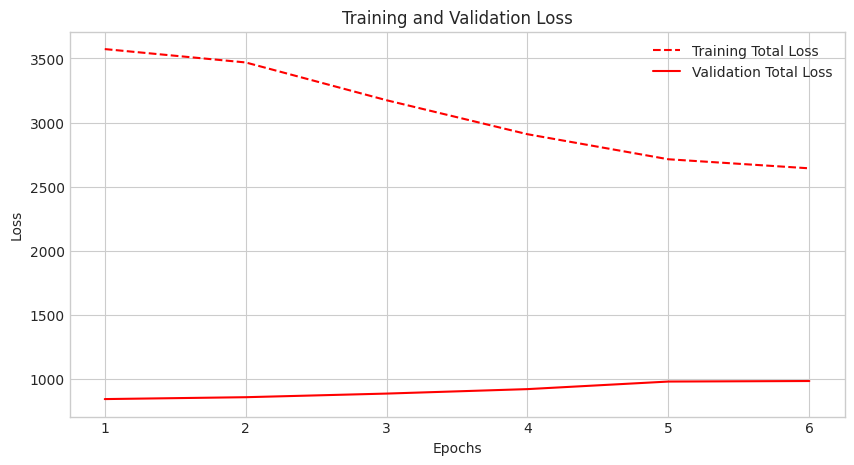

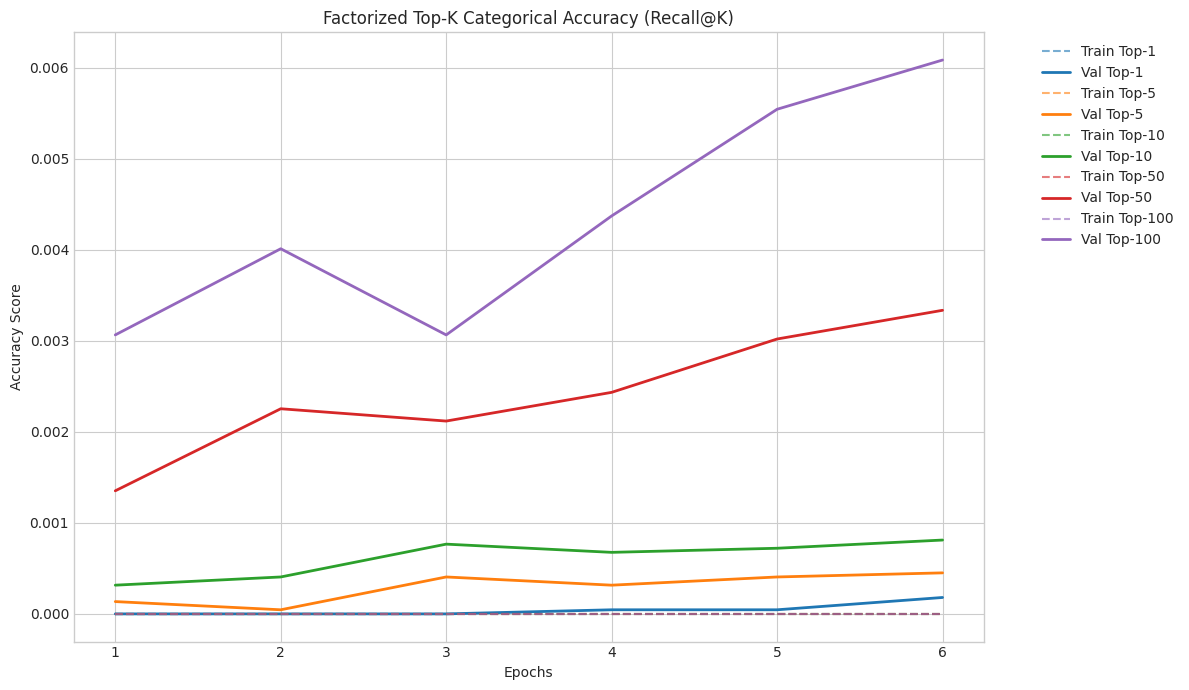

In [ ]:
plot_fashion_recommender_metrics(history)